In [ ]:
#hana
from hdbcli import dbapi
import hana_ml
from hana_ml import dataframe
from hana_ml.dataframe import ConnectionContext

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy
import nltk
import seaborn as sns
import warnings
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import  SGDClassifier
from sklearn.svm import SVC
from textblob import TextBlob
warnings.filterwarnings("ignore")
%matplotlib inline



In [ ]:
conn2 = dataframe.ConnectionContext(
    address="105.203.200.89",
    port=30015,
    user="***",
    password="***"
)

In [ ]:
#flight_hdf = conn2.table("TRAVEL_ROUTE2", schema="XXXX")
sql = 'SELECT COMMENT_TEXT, PROD_HREF FROM "IF_RPA_CRAWLING"."PRODUCT_COMMENTS" WHERE COMMENT_TEXT != \'null\' limit 100'
resenhaHana = conn2.sql(sql)
resenhaHana.dtypes()

In [ ]:
resenhaHana.describe().collect()

In [ ]:
resenhaCsv = pd.read_csv("D:\myprojects\_dados\casasbahia.csv", delimiter=";")
resenhaCsv.head()

In [ ]:
classificacao = resenhaCsv["SENTIMENTO"].replace(["NEGATIVO","POSITIVO"], [0,1])

In [ ]:
classificacao

In [ ]:
resenhaCsv["CLASSFICATION"] = classificacao

In [ ]:
resenhaCsv.head()
resenhaCsv.tail()

In [ ]:
resenhaCsv.isnull().sum()

In [ ]:
print(resenhaCsv.SENTIMENTO.value_counts())

In [ ]:
resenha[(resenhaCsv.SENTIMENTO=='POSITIVO')]

In [ ]:
resenha[(resenhaCsv.SENTIMENTO=='NEGATIVO')]

In [ ]:
resenhaSamplePos = resenhaCsv[(resenhaCsv.SENTIMENTO=='POSITIVO')].sample(n=500)
resenhaSampleNeg = resenhaCsv[(resenhaCsv.SENTIMENTO=='NEGATIVO')].sample(n=500)

In [ ]:
print(resenhaSamplePos.SENTIMENTO.value_counts())

In [ ]:
print(resenhaSampleNeg.SENTIMENTO.value_counts())

In [ ]:
resenhaHana.collect().tail()

In [ ]:
resenhaHana.collect().isnull().sum()

In [ ]:
resenhaHana.collect().tail()

In [ ]:
brancos = []

for i, top, sent, comm, produrl in resenha.itertuples():
    if sent.isspace():
        brancos.append(i)
brancos

In [ ]:
df_list = []
df_list.append(resenhaSamplePos)
df_list.append(resenhaSampleNeg)

df = pd.concat(df_list)
print('Formato do arquivo {}'.format(df.shape))

In [ ]:
# Amostra do Df demostrando que as importações foram realizadas com sucesso.
df.sample(10)

In [441]:
print('tamannho da base {} '.format(df.shape[0]))
df.SENTIMENTO.value_counts()

tamannho da base 1000 


POSITIVO    500
NEGATIVO    500
Name: SENTIMENTO, dtype: int64

In [442]:
print((df.SENTIMENTO.value_counts()/ df.shape[0])*100)

POSITIVO    50.0
NEGATIVO    50.0
Name: SENTIMENTO, dtype: float64


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\a.duek\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


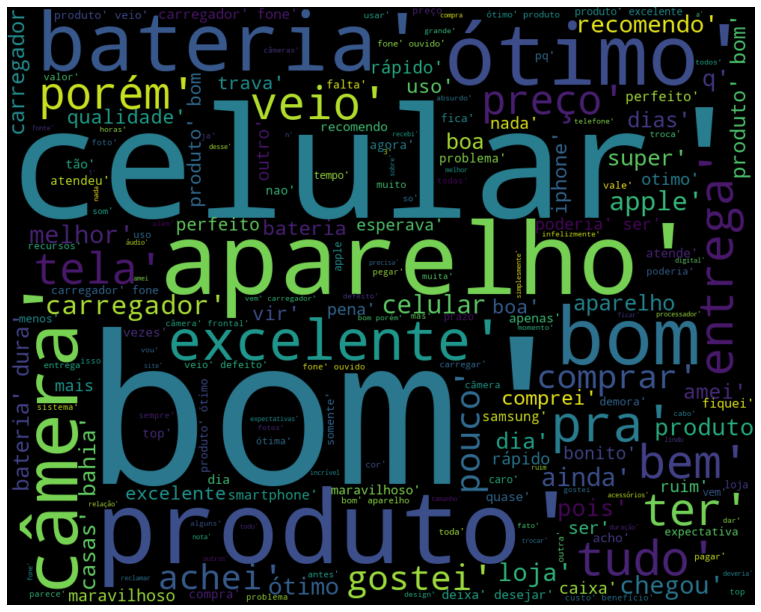

In [490]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')

#carregando a lista de de Stopwords 
stopwordsNltk = nltk.corpus.stopwords.words('portuguese')

from wordcloud import WordCloud
words = []
for i in df.COMMENT_TEXT:
    for p in i.lower().split():
        if p not in stopwordsNltk:
            words.append(p)
words = str(words)

wordcloud = WordCloud(width = 1000, height= 800, margin = 0).generate(words)
plt.figure(figsize=(20,11))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)

In [443]:
np.transpose(stopwordsNltk)
# stopwordsNltk.append('')
# pra

array(['de', 'a', 'o', 'que', 'e', 'é', 'do', 'da', 'em', 'um', 'para',
       'com', 'não', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as',
       'dos', 'como', 'mas', 'ao', 'ele', 'das', 'à', 'seu', 'sua', 'ou',
       'quando', 'muito', 'nos', 'já', 'eu', 'também', 'só', 'pelo',
       'pela', 'até', 'isso', 'ela', 'entre', 'depois', 'sem', 'mesmo',
       'aos', 'seus', 'quem', 'nas', 'me', 'esse', 'eles', 'você', 'essa',
       'num', 'nem', 'suas', 'meu', 'às', 'minha', 'numa', 'pelos',
       'elas', 'qual', 'nós', 'lhe', 'deles', 'essas', 'esses', 'pelas',
       'este', 'dele', 'tu', 'te', 'vocês', 'vos', 'lhes', 'meus',
       'minhas', 'teu', 'tua', 'teus', 'tuas', 'nosso', 'nossa', 'nossos',
       'nossas', 'dela', 'delas', 'esta', 'estes', 'estas', 'aquele',
       'aquela', 'aqueles', 'aquelas', 'isto', 'aquilo', 'estou', 'está',
       'estamos', 'estão', 'estive', 'esteve', 'estivemos', 'estiveram',
       'estava', 'estávamos', 'estavam', 'estivera', 'estivéramos

In [ ]:
def removeStopWords(texto)
    frases = []
    for  (palavras, sentimento) in texto:
        #criamos ma lista Compreheension para extrair apenas as palavras que nao estão na lista_Stop
        semStop = [ p for p in valavras.split() if p not in lista_stop]
        # Inserindo as frases com os Labels (sentimento) ja tratadas pela Lista_Stop
        frases.append((semStop, sentimento))
    return frases

In [ ]:
df.head()

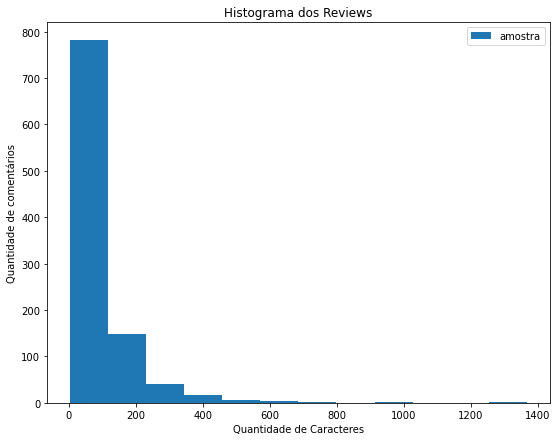

In [370]:
#criando uma nova colunar que contemplará a quantidade de caracteres de cada comentário

df['SIZE_TEXT'] = df['COMMENT_TEXT'].apply(len)

x1 = list(df['SIZE_TEXT'])

plt.figure(figsize=(9,7))
plt.hist([x1], bins = int(180/15),  label='amostra')

plt.xlabel('Quantidade de Caracteres')
plt.ylabel('Quantidade de comentários')
plt.title('Histograma dos Reviews')
plt.legend();

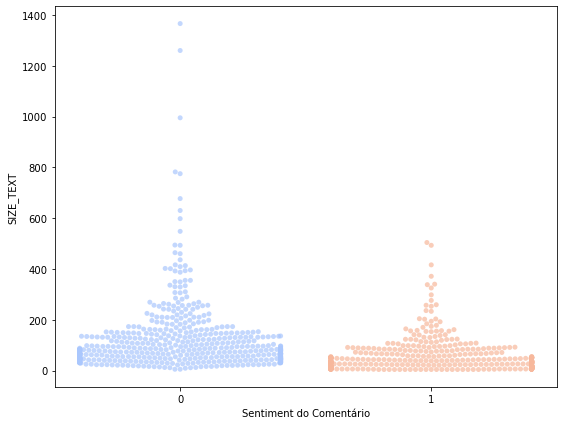

In [371]:
plt.figure(figsize=(9,7))
sns.swarmplot(x="CLASSFICATION", y="SIZE_TEXT", data=df, alpha=0.7, palette='coolwarm');
plt.xlabel('Sentiment do Comentário');

In [372]:
np.random.seed(100)
negativas = df[df['CLASSFICATION'] == 0]
sample_neg = str(negativas.COMMENT_TEXT.sample(2).values).split('\n')

positivas = df[df['CLASSFICATION'] == 1]
sample_pos = str(positivas.COMMENT_TEXT.sample(2).values).split('\n')
                 
print(sample_neg)
print('\n')
print('\n')
print(sample_pos)

["['Pra mim não pega as duas câmeras traseiras .apenas uma funciona. Mas é muito bom . '", " 'Excelente celular. Tudo que eu já esperava da Apple. Uma pena o valor ser tão fora da realidade do Brasil. ']"]




["['Maravilhoso ' 'Muito bom, entrega Rápida!']"]


In [ ]:
# Importando a Biblioteca do Spacy "Utilizada a maior biblioteca ==> lg"
nlp = spacy.load('pt_core_news_lg')

In [ ]:
doc = nlp(u"Isso estava muito ruim.")

for token in doc:
    print(f'{token.text:{10}} {token.pos_:{10}} {token.tag_:{5}} {spacy.explain(token.tag_)} ')

In [373]:
from spacy import displacy
displacy.render(doc, style = 'dep', jupyter = True, options={'distance': 120})

In [374]:
doc1 = nlp(u"no entanto, mais um filme maravilhoso do grande estábulo mestre.")
displacy.render(doc1, style = 'dep', jupyter = True, options={'distance': 85})

In [ ]:
frases_neg = []

for i in negativas.COMMENT_TEXT:
    frases_neg.append(i)

neg_str = ''.join(frases_neg)
doc_neg = nlp(neg_str)

#[ent for ent in doc_neg.ents if ent.label_ == 'ORG']

colors = {'ORG':'red'}
options = {'ents': ['PRODUCT', 'ORG'], 'colors': colors}

for sent in doc_neg.sents:
    if sent.ents:
        displacy.render(nlp(sent.text), style='ent', jupyter=True, options = options)
        

In [ ]:
frases_pos = []

for i in positivas.COMMENT_TEXT:
    frases_pos.append(i)

pos_str = ''.join(frases_pos)
doc_pos = nlp(pos_str)

#[ent for ent in doc_neg.ents if ent.label_ == 'ORG']

colors = {'ORG':'green'}
options = {'ents': ['PRODUCT', 'ORG'], 'colors': colors}

for sent in doc_pos.sents:
    if sent.ents:
        displacy.render(nlp(sent.text), style='ent', jupyter=True, options = options)

In [378]:
def show_ents(doc):
    if doc.ents:
        for ent in doc.ents:
            if ent.label_ == 'ORG':
                print(ent.text + ' - ' + ent.label_ + ' - ' + str(spacy.explain(ent.label_)))
        else:
                print('Entidade não encontrada')

In [379]:
frases = []
for i in df.COMMENT_TEXT:
    frases.append(i)
    
resenha_str = ''.join(frases)
doc_frase = nlp(resenha_str)

In [380]:
show_ents(doc_frase)

SENSACIONAL!!! - ORG - Companies, agencies, institutions, etc.
USB-c - ORG - Companies, agencies, institutions, etc.
Apple - ORG - Companies, agencies, institutions, etc.
Samsung - ORG - Companies, agencies, institutions, etc.
Produto - ORG - Companies, agencies, institutions, etc.
Apple - ORG - Companies, agencies, institutions, etc.
Smartphone - ORG - Companies, agencies, institutions, etc.
Apple - ORG - Companies, agencies, institutions, etc.
Apple - ORG - Companies, agencies, institutions, etc.
Produto compatível - ORG - Companies, agencies, institutions, etc.
Apple - ORG - Companies, agencies, institutions, etc.
👏👏 - ORG - Companies, agencies, institutions, etc.
cor - ORG - Companies, agencies, institutions, etc.
Apple - ORG - Companies, agencies, institutions, etc.
Produto - ORG - Companies, agencies, institutions, etc.
Samsung - ORG - Companies, agencies, institutions, etc.
Samsung - ORG - Companies, agencies, institutions, etc.
Apple - ORG - Companies, agencies, institutions, e

In [381]:
df

,TÓPICO,SENTIMENTO,COMMENT_TEXT,PROD_HREF,CLASSFICATION,SIZE_TEXT
378,GENÉRICO/OUTRO,POSITIVO,"Ótimo produto, sem erros",https://www.casasbahia.com.br/iphone-11-apple-...,1,25
1098,GENÉRICO/OUTRO,POSITIVO,Muito bom do jeito que eu esperava.,https://www.casasbahia.com.br/smartphone-samsu...,1,36
4890,GENÉRICO/OUTRO,POSITIVO,Maravilhoso...tudo aquilo que eu esperava.,https://www.casasbahia.com.br/smartphone-samsu...,1,43
2271,GENÉRICO/OUTRO,POSITIVO,Bom,https://www.casasbahia.com.br/smartphone-samsu...,1,4
7199,GENÉRICO/OUTRO,POSITIVO,Ótimo.,https://www.casasbahia.com.br/smartphone-samsu...,1,7
...,...,...,...,...,...,...
7493,ENTREGA,NEGATIVO,"A caixa veio amassada, isso mostra o descuido ...",https://www.casasbahia.com.br/smartphone-samsu...,0,149
9942,PREÇO,NEGATIVO,"Absurdo um telefone de quase R$ 4.000,00 sem c...",https://www.casasbahia.com.br/iphone-11-apple-...,0,57
7449,CÂMERA,NEGATIVO,"Beleza chama atenção, mas celular em si não é ...",https://www.casasbahia.com.br/smartphone-samsu...,0,198
2073,BATERIA,NEGATIVO,O único ponto que deixa a desejar é a bateria....,https://www.casasbahia.com.br/smartphone-samsu...,0,67


In [382]:
resenha_resumo = df[['COMMENT_TEXT', 'CLASSFICATION']]
print('Formato do Dataframse da Amostra {}'.format(resenha_resumo.shape))
resenha_resumo.head()

Formato do Dataframse da Amostra (1000, 2)


,COMMENT_TEXT,CLASSFICATION
378,"Ótimo produto, sem erros",1
1098,Muito bom do jeito que eu esperava.,1
4890,Maravilhoso...tudo aquilo que eu esperava.,1
2271,Bom,1
7199,Ótimo.,1


In [383]:
# Aplicamos um poucp de REGEX para remover numéricos e caracteres especias
resenha_resumo['COMMENT_TEXT'] = resenha_resumo['COMMENT_TEXT'].str.replace('[^\w\s]','')

In [452]:
from sklearn.model_selection import train_test_split
treino, teste = train_test_split(resenha_resumo, test_size=0.2)

In [409]:
print('Shape dos dados de Treino {}'.format(treino.shape))
treino.CLASSFICATION.value_counts(normalize=True)

Shape dos dados de Treino (800, 2)


1    0.51
0    0.49
Name: CLASSFICATION, dtype: float64

In [410]:
print('Shape dos dados de Teste {}'.format(teste.shape))
teste.CLASSFICATION.value_counts(normalize=True)

Shape dos dados de Teste (200, 2)


0    0.54
1    0.46
Name: CLASSFICATION, dtype: float64

In [453]:
treino = [tuple(x) for x in treino.values]

In [448]:
nltk.download('rslp')
def aplica_Stemmer(texto):
    #stemmer = nltk.stem.SnowballStemmer('portuguese')
    stemmer = nltk.stem.RSLPStemmer()
    
    frases_sem_Stemming = []
    for (palavras, sentimento) in texto:
        com_Stemming = [str(stemmer.stem(p)) for p in palavras.lower().split() if p not in stopwordsNltk]
        frases_sem_Stemming.append((com_Stemming, sentimento))
    return frases_sem_Stemming

[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\a.duek\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping stemmers\rslp.zip.


In [454]:
# Executando nossa função aplica_stemmer
frases_com_Stem_treinamento = aplica_Stemmer(treino)

In [455]:
pd.DataFrame(frases_com_Stem_treinamento, columns=['Frase','Sentimento']).sample(10)

,Frase,Sentimento
253,"[excel, aparelhoporém, fragil]",0
315,"[bom, entreg, rápid]",1
369,"[celul, ótim]",1
257,"[celul, si, topm, pag, not, pret, celul, cheg,...",0
637,"[pens, grand, tel, ser, 57, bem, pequen]",0
490,[bom],1
406,"[vdd, palavr, produt, sab, iri, atend, necess,...",0
419,"[recom, celul, ninguém, deu, problem, carreg, ...",0
698,"[celul, bom, descarreg, rápid, quas, app, nel,...",0
564,"[bat, esgot, rápidocâm, boa]",0


In [456]:
# vamo executar a mesma funçao para a base de Teste, mas antes transformamos os dados de DF para lista de Tuplas
teste = [tuple(x) for x in teste.values]
frases_com_Stem_teste = aplica_Stemmer(teste)

In [420]:
# função para retornar apenas as palavras da frase, sem a classificação (sentimento)
def busca_Palavras(frases):
    todas_Palavras =[]
    for (palavras, sentimento) in frases:
        todas_Palavras.extend(palavras)
    return todas_Palavras

In [457]:
palavras_treinamento = busca_Palavras(frases_com_Stem_treinamento)
palavras_teste = busca_Palavras(frases_com_Stem_teste)

In [458]:
print("Quantidades de palavras na base de Treinamento {}".format(pd.DataFrame(palavras_treinamento).count()))

Quantidades de palavras na base de Treinamento 0    6623
dtype: int64


In [418]:
# função para verificar a quantidade de vezes que a palavra é mencionada
def busca_frequencia(palavras):
    palavras = nltk.FreqDist(palavras)
    return palavras

In [461]:
frequencia_treinamento = busca_frequencia(palavras_treinamento)

In [466]:
frequencia_treinamento.most_common(20)

[('bom', 231),
 ('produt', 193),
 ('celul', 124),
 ('aparelh', 122),
 ('ótim', 120),
 ('carreg', 108),
 ('bat', 92),
 ('compr', 85),
 ('excel', 82),
 ('câm', 71),
 ('fon', 56),
 ('vei', 54),
 ('gost', 54),
 ('dia', 53),
 ('entreg', 52),
 ('ach', 49),
 ('atend', 48),
 ('dur', 46),
 ('preç', 45),
 ('melhor', 44)]

In [463]:
frequencia_teste = busca_frequencia(palavras_teste)

In [467]:
frequencia_teste.most_common(20)

[('produt', 61),
 ('bom', 54),
 ('bat', 39),
 ('celul', 38),
 ('ótim', 36),
 ('aparelh', 35),
 ('câm', 33),
 ('carreg', 26),
 ('rápid', 24),
 ('dia', 24),
 ('compr', 20),
 ('entreg', 20),
 ('dur', 20),
 ('excel', 19),
 ('pouc', 16),
 ('pra', 15),
 ('q', 15),
 ('bem', 15),
 ('fot', 14),
 ('vei', 13)]

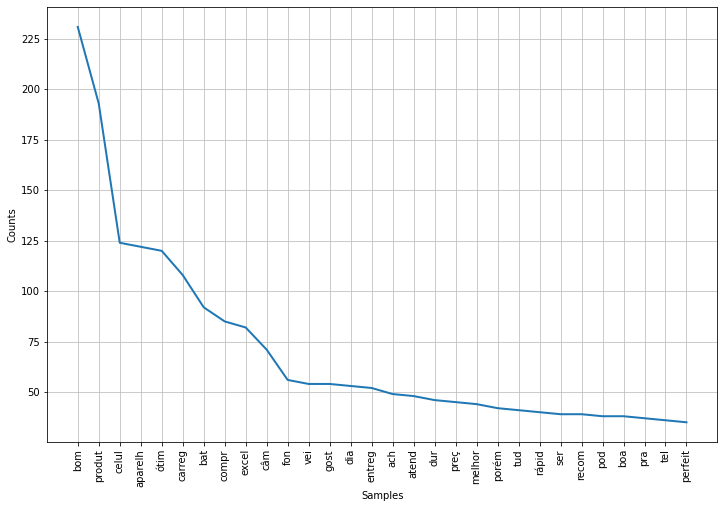

<AxesSubplot:xlabel='Samples', ylabel='Counts'>

In [465]:
plt.figure(figsize=(12,8))
frequencia_treinamento.plot(30, cumulative = False)

In [469]:
#função para retornar somente as palavras únicas

def busca_palavras_unicas(frequencia):
    freq = frequencia.keys()
    return freq

palavras_unicas_treinamento = busca_palavras_unicas(frequencia_treinamento)
palavras_unicas_teste = busca_palavras_unicas(frequencia_teste)


In [470]:
# função para identificar quais palavras únicas estão no documento passado

def extrator_palavras(documento):
    doc = set(documento)
    caracteristicas = {}
    for palavras in palavras_unicas_treinamento:
        caracteristicas['%s' % palavras] = (palavras in doc)
    return caracteristicas

In [428]:
def extrator_palavras_teste(documento):
    doc = set(documento)
    caracteristicas = {}
    for palavras in palavras_unicas_teste:
        caracteristicas['%s' % palavras] = (palavras in doc)
    return caracteristicas

In [472]:
# a Função apply features do NLTK faz o preenchimento se tem ou não (True/False) a caracteristica de acordo com o parametro

base_completa_treinamento = nltk.classify.apply_features(extrator_palavras, frases_com_Stem_treinamento)
base_completa_teste = nltk.classify.apply_features(extrator_palavras_teste, frases_com_Stem_teste)

In [473]:
classificador = nltk.NaiveBayesClassifier.train(base_completa_treinamento)

In [474]:
print(classificador.labels())

[1, 0]


In [475]:
print(classificador.show_most_informative_features(10))

Most Informative Features
                   porém = True                0 : 1      =     28.6 : 1.0
                     pag = True                0 : 1      =     15.5 : 1.0
                    ruim = True                0 : 1      =     14.2 : 1.0
                     vei = True                0 : 1      =     13.8 : 1.0
                  defeit = True                0 : 1      =     12.1 : 1.0
                    falt = True                0 : 1      =     12.1 : 1.0
                    otim = True                1 : 0      =     11.9 : 1.0
                  carreg = True                0 : 1      =     11.5 : 1.0
                     dev = True                0 : 1      =     11.4 : 1.0
                     ter = True                0 : 1      =     11.4 : 1.0
None


In [476]:
print(nltk.classify.accuracy(classificador, base_completa_teste))

0.825


In [477]:
erros = []

for (frase, classe) in base_completa_teste:
    resultado = classificador.classify(frase)
    if resultado != classe:
        erros.append((classe, resultado, frase))

In [478]:
from nltk.metrics import ConfusionMatrix 
esperado = []
previsto = []
for(frase, classe) in base_completa_teste: 
    resultado = classificador.classify(frase)
    previsto.append(resultado)
    esperado.append(classe)
    
matriz = ConfusionMatrix(esperado, previsto) 
print(matriz)

  |  0  1 |
--+-------+
0 |<85>22 |
1 | 13<80>|
--+-------+
(row = reference; col = test)



In [489]:
teste = 'deu problema'

testeStemming = []

#stemmer = nltk.stem.SnowballStemmer('portuguese')
stemmer = nltk.stem.RSLPStemmer()
for (palavras_treinamento) in teste.split():
    comStem = [p for p in palavras_treinamento.split()]
    testeStemming.append(str(stemmer.stem(comStem[0])))

novo = extrator_palavras(testeStemming)
distribuicao = classificador.prob_classify(novo)

for classe in distribuicao.samples():
    
    print('%s: %f' % (classe, distribuicao.prob(classe)))
    if classe == 0:
        print('Probabilidade de ser Negativa')
    else:
        print('Probabilidade de ser Positiva')
    

1: 0.318316
Probabilidade de ser Positiva
0: 0.681684
Probabilidade de ser Negativa
